# Production-Grade Visual Search Engine

In [1]:
import os
import glob
import pickle
import shutil
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

# TensorFlow & Keras imports
import keras
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.neighbors import NearestNeighbors
from IPython.display import FileLink, display

Install & Import ChromaDB for vector database functionality

In [3]:
!pip install -q chromadb

In [4]:
import chromadb

## SETUP & DATASET PATHS

In [5]:
import os

print(os.listdir("/kaggle/input/datasets/sapnilpatel/tanishq-jewellery-dataset/Jewellery_Data"))

['necklace', 'ring']


In [7]:
# Path for the Tanishq Jewellery dataset on Kaggle
path = '/kaggle/input/datasets/sapnilpatel/tanishq-jewellery-dataset/Jewellery_Data'

# Gather image paths across all subfolders recursively with extension matching
image_extensions = ['**/*.jpg', '**/*.JPG', '**/*.jpeg', '**/*.JPEG', '**/*.png', '**/*.PNG']

image_paths = []
for ext in image_extensions:
    image_paths.extend(glob.glob(os.path.join(path, ext), recursive=True))

image_paths = sorted(list(set(image_paths)))
print(f"Total images found in dataset: {len(image_paths)}")

# To Validate: Print the first 3 paths to verify
if len(image_paths) > 0:
    print("\nSample image paths:")
    for p in image_paths[:3]:
        print(p)
else:
    # Debugging check if directory is empty or mounted differently
    print(f"\nDirectory contents of '{path}':", os.listdir(path))

Total images found in dataset: 490

Sample image paths:
/kaggle/input/datasets/sapnilpatel/tanishq-jewellery-dataset/Jewellery_Data/necklace/necklace_1.jpg
/kaggle/input/datasets/sapnilpatel/tanishq-jewellery-dataset/Jewellery_Data/necklace/necklace_10.jpg
/kaggle/input/datasets/sapnilpatel/tanishq-jewellery-dataset/Jewellery_Data/necklace/necklace_100.jpg


## LOAD PRETRAINED MODEL (Feature Extractor)

In [9]:
backbone = MobileNetV2(
    weights="imagenet",
    include_top=False,
    pooling="avg"
)

# We use MobileNetV2 pretrained on ImageNet
# include_top=False removes classification head; pooling='avg' provides 1280-D vector

/tmp/ipykernel_58/3851746486.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  backbone = MobileNetV2(
2026-08-15 16:56:40.602811: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [10]:
# Set model for inference / feature extraction only
backbone.trainable = False  
print("MobileNetV2 Feature Extractor loaded successfully.")
print(f"Number of layers: {len(backbone.layers)}")

MobileNetV2 Feature Extractor loaded successfully.
Number of layers: 155


## HELPER FUNCTIONS

In [12]:
def preprocess_img(img_path):
    """
    Loads an image, resizes to (224, 224), converts to array, 
    and applies MobileNetV2 preprocess_input scaling to [-1, 1].
    """
    img = load_img(img_path, target_size=(224, 224))
    img_array = img_to_array(img)
    preprocessed_img = preprocess_input(img_array)
    return preprocessed_img

def extract_embedding(img_path):
    """
    Preprocesses image, expands dimensions to 4D batch (1, 224, 224, 3),
    and returns its 1280-dimensional feature embedding vector.
    """
    preprocessed_img = preprocess_img(img_path)
    img = np.expand_dims(preprocessed_img, axis=0)
    embedding = backbone.predict(img, verbose=0)
    return embedding  # Shape: (1, 1280)

## BUILDING THE CATALOG EMBEDDINGS

In [13]:
feature_list = []
valid_paths = []

print("\nExtracting feature embeddings for catalog images...")
for img_path in tqdm(image_paths):
    try:
        emb = extract_embedding(img_path)
        feature_list.append(emb)
        valid_paths.append(img_path)
    except Exception as e:
        # Best practice: Skip corrupt or unreadable image files gracefully
        print(f"Skipping unreadable image {img_path}: {e}")

# Squeeze list of (1, 1280) into matrix of shape (N, 1280)
feature_list = np.squeeze(np.array(feature_list))
print(f"\nExtracted embeddings matrix shape: {feature_list.shape}")


Extracting feature embeddings for catalog images...


100%|██████████| 490/490 [01:02<00:00,  7.83it/s]


Extracted embeddings matrix shape: (490, 1280)


## VISUALIZATION FUNCTION

In [14]:
def plot_image_search_results(query_path, matched_paths, scores):
    """
    Unified visualization function for query image and nearest neighbors.
    Parameters:
    - query_path (str): File path to the query image.
    - matched_paths (list): List of file paths for retrieved neighbor images.
    - scores (list): List of similarity or distance scores for matches.
    """
    total_images = len(matched_paths) + 1
    
    # Set up dynamic figure width based on number of results
    plt.figure(figsize=(3 * total_images, 4))
    
    # 1. Plot Query Image
    plt.subplot(1, total_images, 1)
    plt.imshow(Image.open(query_path))
    plt.title("Query Image", fontweight="bold")
    plt.axis('off')
    
    # 2. Plot Retrieved Neighbor Images
    for i, (path, score) in enumerate(zip(matched_paths, scores)):
        plt.subplot(1, total_images, i + 2)
        plt.imshow(Image.open(path))
        plt.title(f"Score: {score:.2f}", fontsize=10)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

## SIMILARITY SEARCH DEMOS (Manual Cosine & NearestNeighbors)

In [16]:
test_query_idx = 0
query_path = valid_paths[test_query_idx]
query_embedding = extract_embedding(query_path)

### Approach A: Manual Cosine Similarity Search


--- Manual Search Results ---


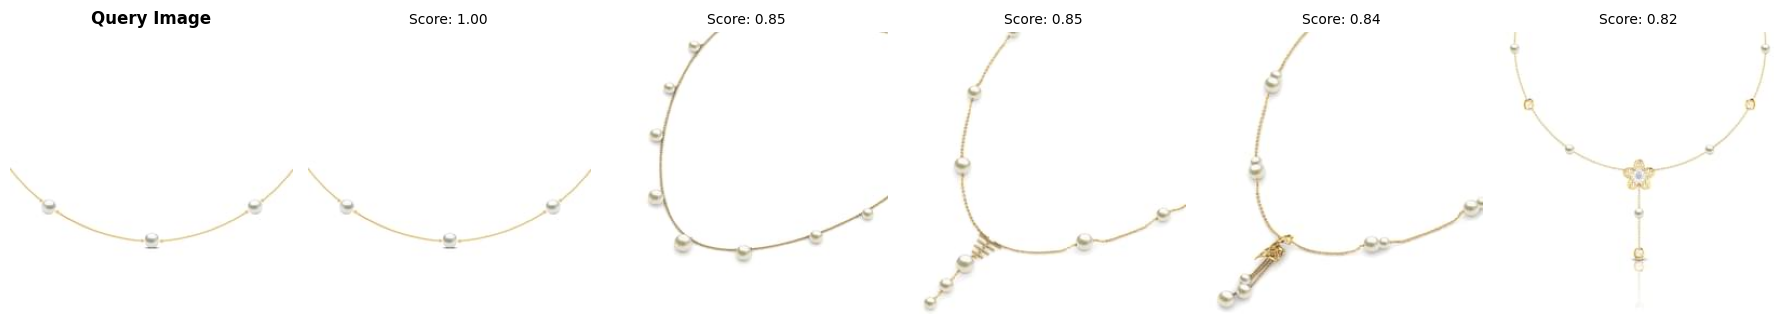

In [17]:
sim_scores = cosine_similarity(query_embedding, feature_list)[0]
top_k = 5
sorted_indices = np.argsort(sim_scores)[-top_k:][::-1]

matched_paths_manual = [valid_paths[idx] for idx in sorted_indices]
scores_manual = [sim_scores[idx] for idx in sorted_indices]

print("\n--- Manual Search Results ---")
plot_image_search_results(query_path, matched_paths_manual, scores_manual)

### Approach B: Scikit-Learn NearestNeighbors Search


--- NearestNeighbors Search Results ---


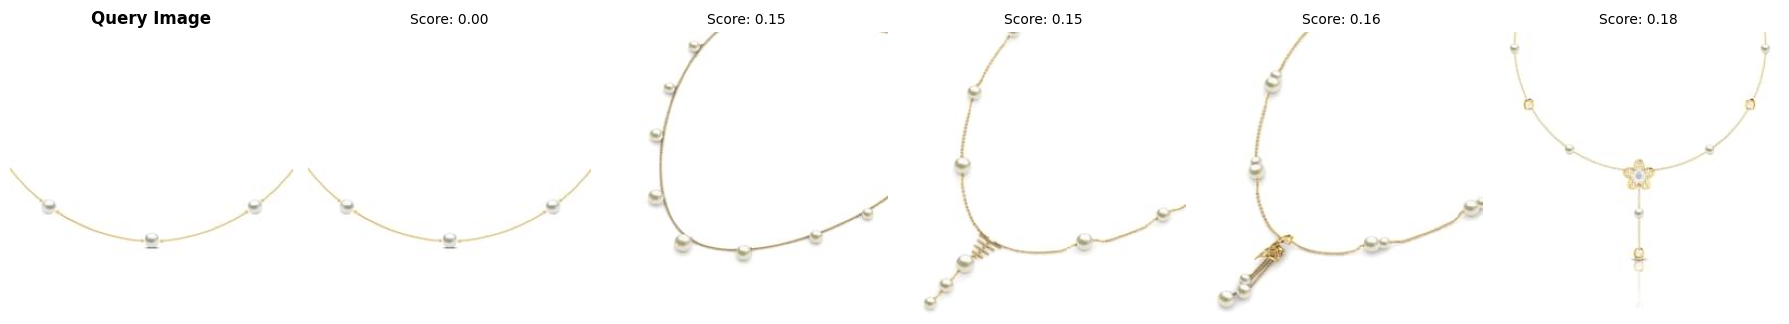

In [18]:
neighbors = NearestNeighbors(n_neighbors=top_k, algorithm='brute', metric='cosine')
neighbors.fit(feature_list)

distances, indices = neighbors.kneighbors(query_embedding)

matched_paths_nn = [valid_paths[idx] for idx in indices[0]]
scores_nn = distances[0]

print("\n--- NearestNeighbors Search Results ---")
plot_image_search_results(query_path, matched_paths_nn, scores_nn)

## VECTOR DATABASE INTEGRATION (ChromaDB)

In [20]:
# Create directory for persistent Chroma DB storage
chroma_db_dir = '/kaggle/working/data/chroma_db'

# Initialize persistent client (saves index to disk so it can be exported)
chroma_client = chromadb.PersistentClient(
    path=chroma_db_dir,
    settings=chromadb.Settings(anonymized_telemetry=False)
)

# Create/Get collection with Cosine distance metric configuration
collection = chroma_client.get_or_create_collection(
    name="jewellery_catalog",
    metadata={"hnsw:space": "cosine"}
)

# may try 'l2' stands for Squared L2 / Euclidean distance (need more search, depends on your case and goal)

# Build string IDs and convert embeddings matrix to python lists for ChromaDB
ids = [str(i) for i in range(len(feature_list))]
embeddings_list = feature_list.tolist()

# Insert vectors into ChromaDB along with file paths as 'uris' (matching lab structure)
collection.add(
    ids=ids,
    embeddings=embeddings_list,
    uris=valid_paths
)

print(f"\nSuccessfully stored {collection.count()} items in ChromaDB.")


Successfully stored 490 items in ChromaDB.


### Query ChromaDB


--- ChromaDB Search Results ---


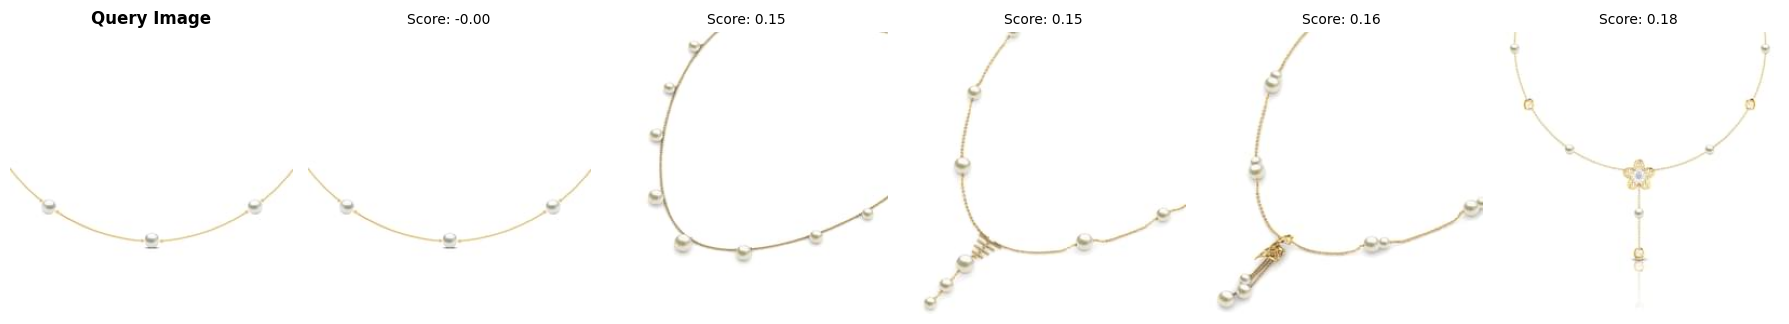

In [21]:
chroma_results = collection.query(
    query_embeddings=query_embedding.tolist(),
    n_results=top_k,
    include=["uris", "distances"]
)

chroma_matched_uris = chroma_results['uris'][0]
chroma_matched_distances = chroma_results['distances'][0]

print("\n--- ChromaDB Search Results ---")
plot_image_search_results(query_path, chroma_matched_uris, chroma_matched_distances)

## EVALUATING THE SEARCH ENGINE (Precision@K Check)

In [22]:
def evaluate_precision_at_k(valid_paths, feature_list, k=5):
    """
    Evaluates retrieval quality using Precision@K based on folder category labels.
    """
    labels = [os.path.basename(os.path.dirname(p)) for p in valid_paths]
    unique_labels = set(labels)
    
    if len(unique_labels) > 1:
        sim_matrix = cosine_similarity(feature_list, feature_list)
        precisions = []
        
        for i in range(len(valid_paths)):
            query_label = labels[i]
            sorted_idx = np.argsort(sim_matrix[i])[::-1]
            
            # Ignore self-match at index 0 and retrieve top-k indices
            top_k_indices = sorted_idx[1:k+1]
            retrieved_labels = [labels[idx] for idx in top_k_indices]
            
            matches = sum(1 for l in retrieved_labels if l == query_label)
            precisions.append(matches / k)
            
        mean_precision = np.mean(precisions) * 100
        print(f"\n--- Quantitative Retrieval Evaluation ---")
        print(f"Mean Precision@{k}: {mean_precision:.2f}% across {len(unique_labels)} categories.")
    else:
        print("\n--- Evaluation Note ---")
        print("Dataset images are stored in a single folder without class subfolders.")
        print("Precision@K skipped (requires category ground-truth folder structures).")

evaluate_precision_at_k(valid_paths, feature_list, k=5)


--- Quantitative Retrieval Evaluation ---
Mean Precision@5: 98.86% across 2 categories.


## SAVING & PACKAGING ARTIFACTS FOR DEPLOYMENT

In [23]:
output_dir = '/kaggle/working/data'

# Save Pickle metadata dictionary (from lab)
payload = {
    'features': feature_list,
    'paths': valid_paths
}
pkl_filepath = os.path.join(output_dir, 'product_metadata.pkl')
with open(pkl_filepath, 'wb') as f:
    pickle.dump(payload, f)

# Compress ChromaDB directory into a single ZIP file for downloading
shutil.make_archive('/kaggle/working/data/chroma_db', 'zip', chroma_db_dir)

print("\nDeployment artifacts generated successfully:")
print(f" - Pickle Metadata: {pkl_filepath}")
print(f" - ChromaDB ZIP: /kaggle/working/data/chroma_db.zip")


Deployment artifacts generated successfully:
 - Pickle Metadata: /kaggle/working/data/product_metadata.pkl
 - ChromaDB ZIP: /kaggle/working/data/chroma_db.zip


### GENERATE DOWNLOAD LINKS

In [24]:
print("\nClick the links below to download the deployment files:")
display(FileLink('data/product_metadata.pkl'))
display(FileLink('data/chroma_db.zip'))


Click the links below to download the deployment files:


/kaggle/working/data/product_metadata.pkl

/kaggle/working/data/chroma_db.zip